# Лабораторна робота № 1 — Регресійне моделювання даних

**Варіант 5.** Набір даних: **Breast Cancer Wisconsin (Diagnostic)**.
Цільова ознака: `diagnosis` (діагноз).

**Мета роботи.** Сформулювати задачу регресії, побудувати коректний експеримент
машинного навчання, створити базову модель, навчити та порівняти кілька
регресійних моделей за крос-валідацією, оцінити якість на тестовій вибірці,
проаналізувати похибки й обґрунтовано обрати фінальну модель.

Робота є продовженням **практичної роботи № 1**: використовуємо той самий набір
даних, той самий поділ на train/test і той самий preprocessing-pipeline, а також
перевіряємо сформульовані там гіпотези.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold, RepeatedKFold,
                                     cross_validate, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures, FunctionTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# 5-fold крос-валідація; shuffle — бо у вихідному файлі об'єкти впорядковані не випадково
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RMSE — основна метрика вибору; MAE та R2 — додаткові
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
print("sklearn CV:", CV)

sklearn CV: KFold(n_splits=5, random_state=42, shuffle=True)


## 1. Постановка прикладної задачі

**Предметна область.** Медична діагностика, цитологія новоутворень молочної залози.
Дані отримані у Вісконсинському університеті: з оцифрованого зображення
тонкоголкової аспіраційної біопсії (FNA) автоматично вимірюються геометричні та
текстурні характеристики клітинних ядер.

**Що описується даними.** Один рядок = одне новоутворення (один пацієнт).
Для кожного з 10 вимірюваних властивостей ядра (`radius`, `texture`, `perimeter`,
`area`, `smoothness`, `compactness`, `concavity`, `concave_points`, `symmetry`,
`fractal_dimension`) наведено три агрегати по клітинах зразка: `_mean` (середнє),
`_se` (стандартна похибка), `_worst` (середнє трьох найбільших) — разом 30 ознак.

**Цільова змінна.** `diagnosis` у кодуванні `scikit-learn`:
`0 = malignant` (злоякісне), `1 = benign` (доброякісне).

**Чому це задача регресії.** За умовою варіанта модель повинна повертати **число**,
а не мітку класу. Ми будуємо $\hat y = f(x)$, де $\hat y$ — неперервна величина,
яку інтерпретуємо як **оцінку доброякісності**: чим ближче до 1, тим більше
ознак свідчить на користь доброякісного новоутворення; чим ближче до 0 — тим
більше на користь злоякісного. Модель навчається мінімізувати квадратичну похибку
відносно $y\in\{0,1\}$, оцінюється регресійними метриками (MAE, RMSE, $R^2$), і
поріг рішення в неї не «вшитий».

Треба чесно зазначити: цільова змінна бінарна, тому це **регресія на бінарну
ціль** (лінійна ймовірнісна модель). Це має наслідки, які видно далі в аналізі
залишків, і я їх окремо обговорюю в розділах 11–13.

**Практичний зміст.** Отримане число — це неперервна **шкала ризику**, а не
діагноз. Практична користь саме від неперервності: значення близько 0.05 чи 0.95
означають упевнений випадок, а 0.4–0.6 — межову ситуацію, яку варто винести на
пріоритетний перегляд лікарем. Дискретна мітка такої градації не дає.

**Для чого це може бути корисним.** Сортування черги на дообстеження (тріаж):
випадки з низькою оцінкою доброякісності отримують вищий пріоритет; межові
випадки маркуються як такі, що потребують другої думки. Це інструмент
**підтримки** рішення, він не замінює гістологічну верифікацію.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy().rename(columns={"target": "diagnosis"})


# Ті самі назви ознак, що й у практичній роботі № 1
def to_snake(col):
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col


df.columns = [c if c == "diagnosis" else to_snake(c) for c in df.columns]
FEATURES = [c for c in df.columns if c != "diagnosis"]

print("Кодування цілі у sklearn:", dict(enumerate(data.target_names)))
print("Розмір таблиці:", df.shape)
df.head()

Кодування цілі у sklearn: {0: np.str_('malignant'), 1: np.str_('benign')}
Розмір таблиці: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Аналіз індивідуального набору даних

Детальний EDA виконано у практичній роботі № 1. Тут повторюю лише той мінімум,
який вимагає завдання ЛР № 1, — щоб цей ноутбук читався самостійно.

In [3]:
audit = {
    "кількість об'єктів": len(df),
    "кількість вхідних ознак": len(FEATURES),
    "типи ознак": dict(df[FEATURES].dtypes.astype(str).value_counts()),
    "категоріальні ознаки": int(sum(df[FEATURES].dtypes == "object")),
    "діапазон цілі": (float(df["diagnosis"].min()), float(df["diagnosis"].max())),
    "унікальних значень цілі": int(df["diagnosis"].nunique()),
    "пропущені значення": int(df.isnull().sum().sum()),
    "повні дублікати": int(df.duplicated().sum()),
    "константні стовпці": int((df.nunique() <= 1).sum()),
}
for k, v in audit.items():
    print(f"{k:28} {v}")

print("\nРозподіл цілі:")
print(df["diagnosis"].value_counts().rename({0: "0 malignant", 1: "1 benign"}).to_string())
print(df["diagnosis"].value_counts(normalize=True).round(3).to_string())

кількість об'єктів           569
кількість вхідних ознак      30
типи ознак                   {'float64': np.int64(30)}
категоріальні ознаки         0
діапазон цілі                (0.0, 1.0)
унікальних значень цілі      2
пропущені значення           0
повні дублікати              0
константні стовпці           0

Розподіл цілі:
diagnosis
1 benign       357
0 malignant    212
diagnosis
1    0.627
0    0.373


In [4]:
# Потенційно аномальні значення — критерій IQR (як у ПР № 1)
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())


out = pd.Series({c: iqr_outliers(df[c]) for c in FEATURES}).sort_values(ascending=False)
print("Ознак із хоча б одним IQR-викидом:", int((out > 0).sum()), "з", len(FEATURES))
print("Топ-5:\n", out.head(5).to_string())
print(f"\nЧастка позначених значень: {out.sum() / (len(df) * len(FEATURES)) * 100:.1f}%")
print("\nСлужбових / ідентифікаційних стовпців немає: окремого ID у наборі не передбачено.")

Ознак із хоча б одним IQR-викидом: 29 з 30
Топ-5:
 area_se          65
radius_se        38
perimeter_se     38
area_worst       35
smoothness_se    30

Частка позначених значень: 3.6%

Службових / ідентифікаційних стовпців немає: окремого ID у наборі не передбачено.


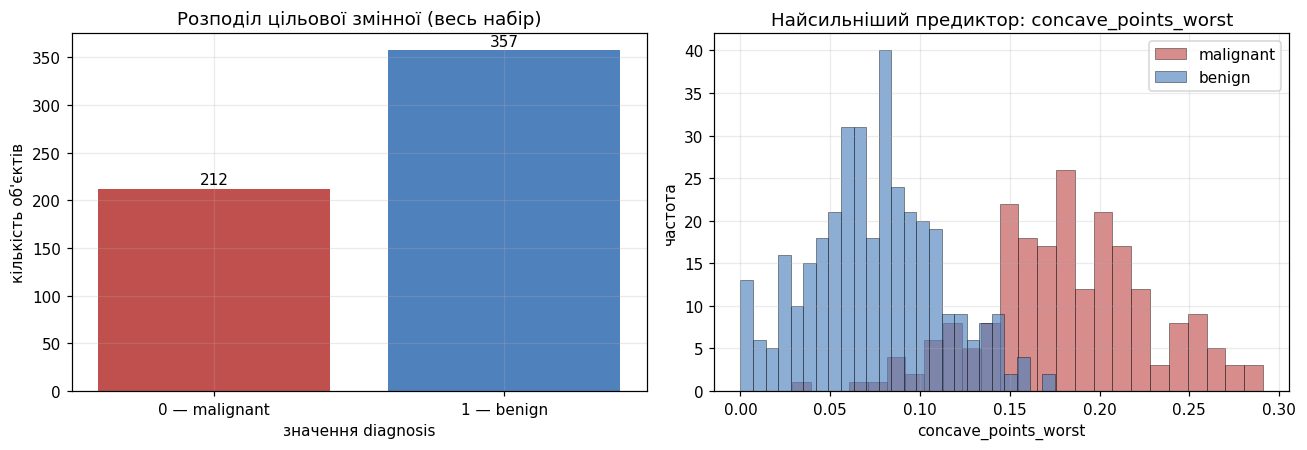

Ціль набуває лише двох значень — [np.int64(0), np.int64(1)] — тому 'розподіл' це дві точки, а не неперервна крива.


In [5]:
# Візуалізація цільової змінної + її зв'язок із найсильнішим предиктором.
# Ознаку не підбираю за даними — беру ту, що виявилася найсильнішою в ПР № 1.
strongest = "concave_points_worst"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = df["diagnosis"].value_counts().sort_index()
axes[0].bar(["0 — malignant", "1 — benign"], counts.values, color=["#c0504d", "#4f81bd"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center")
axes[0].set_xlabel("значення diagnosis")
axes[0].set_ylabel("кількість об'єктів")
axes[0].set_title("Розподіл цільової змінної (весь набір)")

for cls, color, name in [(0, "#c0504d", "malignant"), (1, "#4f81bd", "benign")]:
    axes[1].hist(df.loc[df["diagnosis"] == cls, strongest], bins=25, alpha=0.65,
                 color=color, label=name, edgecolor="black", linewidth=0.4)
axes[1].set_xlabel(strongest)
axes[1].set_ylabel("частота")
axes[1].set_title(f"Найсильніший предиктор: {strongest}")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG / "01_target_and_strongest_feature.png")
plt.show()

print("Ціль набуває лише двох значень —", sorted(df['diagnosis'].unique()),
      "— тому 'розподіл' це дві точки, а не неперервна крива.")

**Висновки аналізу.**

* **569 об'єктів, 30 вхідних ознак**, усі `float64` і за змістом числові неперервні.
  Категоріальних ознак немає → кодування не потрібне.
* **Пропущених значень 0, повних дублікатів 0, константних стовпців 0**,
  службових/ID-стовпців немає → відповідні операції очищення не застосовуються.
* **Діапазон цілі — `{0, 1}`**, лише два унікальні значення. Це головна
  особливість варіанта: формально ми розв'язуємо регресію, але ціль бінарна.
  Наслідок — нижня межа досяжного RMSE тут не нульова у практичному сенсі, а
  залишки будуть двосмуговими (див. розділ 11).
* **Потенційні викиди за IQR є майже в усіх ознаках** (~3.9 % значень). У ПР № 1
  я перевірила їх походження: усі 49 екстремальних `area_se` належать злоякісним
  новоутворенням, тобто це предметно валідні великі неоднорідні ядра, а не
  помилки вимірювання. **Видаляти їх не буду**; замість цього серед кандидатів
  перевіряю стійке масштабування (`RobustScaler`) і `log1p`-трансформацію.
* Класи незбалансовані помірно (63 % / 37 %), тому поділ роблю зі `stratify`.

## 3. План експерименту

**План складено до навчання будь-якої моделі** — щоб вибір методів не підлаштовувався
під уже побачені метрики.

| Пункт плану | Рішення | Чому саме так |
|---|---|---|
| Поділ даних | `train_test_split(test_size=0.2, random_state=42, stratify=y)` | рекомендовані 80/20; `stratify` — через дисбаланс 63/37; **той самий поділ, що й у ПР № 1**, тож висновки практичної переносяться коректно |
| Крос-валідація | `KFold(n_splits=5, shuffle=True, random_state=42)` на **навчальній** вибірці | k=5 за рекомендацією; `shuffle` — бо у вихідному файлі об'єкти впорядковані не випадково |
| Baseline | `DummyRegressor(strategy="mean")` | завжди передбачає середнє `y_train`; його RMSE ≈ стандартне відхилення цілі, і це той мінімум, який зобов'язана перевищити будь-яка модель |
| Кандидатні моделі | (1) `LinearRegression`; (2) поліноміальна регресія $d=2$; (3) `Ridge`; (4) `Lasso`; (5) `ElasticNet`; (6) поліном $d=2$ + `Ridge` | пункти (1) і (2) вимагає завдання; регуляризовані моделі — прямий наслідок гіпотези 2 з ПР № 1 про мультиколінеарність (15 пар $\|r\|>0.95$) |
| Гіперпараметри | `GridSearchCV` по сітці `alpha` (та `l1_ratio` для ElasticNet) **усередині** тієї самої 5-fold CV | вибір параметра — це теж навчання, тестова вибірка тут не використовується |
| Метрики | основна — **RMSE**; додаткові — **MAE** і **$R^2$** | RMSE рекомендована завданням і сильніше карає великі похибки, а в задачі тріажу дорого коштує саме груба помилка на окремому пацієнті |
| Критерій вибору фінальної моделі | найменша CV RMSE; за перекриття інтервалів «середнє ± std» — перевага **простішій і стабільнішій** моделі | різниця в третьому знаку не є підставою брати складнішу модель |
| Тестова вибірка | **не використовується** до моменту фінального оцінювання | інакше метрики будуть оптимістично зміщені |

Додатково перевіряю **5 робочих гіпотез із ПР № 1** (розділ 9): корисність
`_worst`-ознак, надлишковість кластера `radius/perimeter/area`, шумові ознаки,
`log1p` для `_se`, `RobustScaler` проти `StandardScaler`.

In [6]:
X = df[FEATURES].copy()
y = df["diagnosis"].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("train:", X_train.shape, " test:", X_test.shape)
print("частка benign: train %.3f | test %.3f" % (y_train.mean(), y_test.mean()))
print("\nПоділ ідентичний ПР № 1 (ті самі дані, random_state і stratify).")

train: (455, 30)  test: (114, 30)
частка benign: train 0.626 | test 0.632

Поділ ідентичний ПР № 1 (ті самі дані, random_state і stratify).


## 4. Попередня обробка даних

Беру **готовий pipeline із практичної роботи № 1** і не змінюю його без причини:

```
числові ознаки (усі 30) -> SimpleImputer(median) -> StandardScaler
```

**Що застосовано і чому:**

* `StandardScaler` — масштаби ознак відрізняються приблизно у $10^5$ разів
  (`area_worst` до ≈ 3430 проти `fractal_dimension_se` ≈ 0.03). Для лінійних
  моделей з регуляризацією це критично: без масштабування штраф $\alpha\|w\|^2$
  карав би ознаки нерівномірно, лише через одиниці вимірювання.
* `SimpleImputer(median)` — на цих даних це **no-op** (пропусків немає). Лишаю
  свідомо: pipeline має лишатися придатним до нових даних, де пропуск можливий.

**Що НЕ застосовано і чому:**

| Операція | Чому не застосовано |
|---|---|
| Обробка пропусків | пропусків 0 |
| Видалення дублікатів | дублікатів 0 |
| Кодування категорій | категоріальних ознак немає |
| Видалення неінформативних стовпців | службових/ID/константних стовпців немає |
| Видалення викидів | перевірено в ПР № 1: екстремуми предметно валідні й корелюють із ціллю |
| Створення нових ознак | поліноміальне розширення перевіряю як окрему **модель**, а не як частину препроцесингу |

Усі перетворення навчаються **лише на train**: препроцесор вкладено всередину
`Pipeline`, тому під час крос-валідації він навчається на train-частині кожного
fold окремо. Це і є захист від data leakage.

In [7]:
SE_FEATURES = [c for c in FEATURES if c.endswith("_se")]


# Препроцесор ПР № 1 із перемикачами для перевірки гіпотез
def build_preprocessor(scaler="standard", log_se=False, features=None):
    feats = list(features) if features is not None else list(FEATURES)
    sc = StandardScaler() if scaler == "standard" else RobustScaler()

    if not log_se:
        num = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", sc)])
        return ColumnTransformer([("num", num, feats)], remainder="drop")

    se = [c for c in feats if c in SE_FEATURES]
    rest = [c for c in feats if c not in SE_FEATURES]
    se_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler() if scaler == "standard" else RobustScaler()),
    ])
    rest_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", sc)])
    return ColumnTransformer([("se", se_pipe, se), ("num", rest_pipe, rest)], remainder="drop")


BASE_PRE = build_preprocessor()
print(BASE_PRE)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave_points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave_points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
          

In [8]:
# Перевірка спадковості: чи збігається препроцесор із збереженим у ПР № 1 артефактом
art = Path("../../practical01/data/preprocessor.joblib")
if art.exists():
    import joblib
    saved = joblib.load(art)
    a = saved["preprocessor"].transform(X_test)
    b = build_preprocessor().fit(X_train).transform(X_test)
    print("Артефакт ПР № 1 знайдено.")
    print("  ознаки збігаються :", saved["features"] == FEATURES)
    print("  random_state / test_size:", saved["random_state"], saved["test_size"])
    print("  максимальна різниця перетворення:", float(np.abs(a - b).max()))
else:
    print("Артефакт ПР № 1 не знайдено (він у .gitignore) — препроцесор перебудовано за тим самим кодом.")
    print("Щоб отримати артефакт, виконайте practical01/notebook/practical01.ipynb.")

Артефакт ПР № 1 знайдено.
  ознаки збігаються : True
  random_state / test_size: 42 0.2
  максимальна різниця перетворення: 0.0


## 5. Базова модель (baseline)

`DummyRegressor(strategy="mean")` завжди передбачає середнє значення `y_train`
незалежно від ознак. Його RMSE дорівнює стандартному відхиленню цілі на вибірці,
а $R^2$ на крос-валідації буде приблизно 0 (трохи нижче нуля через розбіжність
середніх між fold). Це і є мінімальний рівень, який зобов'язана перевищити
будь-яка змістовна модель.

In [9]:
RESULTS = []


# 5-fold CV на навчальній вибірці; повертає середні та std за трьома метриками
def cv_eval(name, model, params="—", store=True, X=X_train, yv=y_train):
    cvres = cross_validate(model, X, yv, cv=CV, scoring=SCORING, return_train_score=True)
    row = {
        "model": name,
        "params": params,
        "CV RMSE": -cvres["test_rmse"].mean(),
        "CV std": cvres["test_rmse"].std(),
        "CV MAE": -cvres["test_mae"].mean(),
        "CV R2": cvres["test_r2"].mean(),
        "train RMSE": -cvres["train_rmse"].mean(),
    }
    if store:
        RESULTS.append(row)
    return row


baseline = Pipeline([("pre", build_preprocessor()), ("model", DummyRegressor(strategy="mean"))])
row = cv_eval("Baseline (mean)", baseline)

print(f"std(y_train)          = {y_train.std(ddof=0):.4f}")
print(f"Baseline CV RMSE      = {row['CV RMSE']:.4f}  (± {row['CV std']:.4f})")
print(f"Baseline CV MAE       = {row['CV MAE']:.4f}")
print(f"Baseline CV R2        = {row['CV R2']:.4f}")

std(y_train)          = 0.4838
Baseline CV RMSE      = 0.4859  (± 0.0173)
Baseline CV MAE       = 0.4702
Baseline CV R2        = -0.0288


## 6. Кандидатні регресійні моделі

Будую шість кандидатів. Перші два вимагає завдання, решта — наслідок висновків
ПР № 1 про сильну мультиколінеарність (15 пар ознак з $|r|>0.95$), через яку
коефіцієнти звичайної лінійної регресії стають нестабільними.

* **Linear Regression** — метод найменших квадратів без регуляризації.
* **Polynomial d=2** — поліноміальне розширення (30 ознак → 495 з урахуванням
  попарних добутків) + звичайна лінійна регресія. Ознак стає більше, ніж об'єктів
  у навчальній вибірці (455), тож очікую перенавчання.
* **Ridge** — L2-регуляризація: штраф $\alpha\|w\|_2^2$ стискає коефіцієнти,
  розподіляючи вагу між корельованими ознаками.
* **Lasso** — L1-регуляризація: штраф $\alpha\|w\|_1$ занулює частину
  коефіцієнтів, тобто виконує відбір ознак.
* **ElasticNet** — комбінація L1 і L2.
* **Polynomial d=2 + Ridge** — чи рятує регуляризація перенавчений поліном.

Гіперпараметри підбираю `GridSearchCV` **усередині** тієї самої 5-fold CV на
навчальній вибірці. Тестова вибірка на цьому етапі не торкається.

In [10]:
def pipe(model, **pre_kw):
    return Pipeline([("pre", build_preprocessor(**pre_kw)), ("model", model)])


def poly_pipe(model, degree=2, **pre_kw):
    return Pipeline([
        ("pre", build_preprocessor(**pre_kw)),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", model),
    ])


# --- моделі без гіперпараметрів ---
cv_eval("Linear Regression", pipe(LinearRegression()))
cv_eval("Polynomial d=2", poly_pipe(LinearRegression()), params="degree=2")

n_poly = PolynomialFeatures(degree=2, include_bias=False).fit(
    np.zeros((2, len(FEATURES)))).n_output_features_
print(f"Ознак після поліноміального розширення d=2: {n_poly} при {len(X_train)} об'єктах у train.")
print("Кількість параметрів перевищує кількість спостережень → чекаю перенавчання.")

Ознак після поліноміального розширення d=2: 495 при 455 об'єктах у train.
Кількість параметрів перевищує кількість спостережень → чекаю перенавчання.


In [11]:
# --- підбір гіперпараметрів ---
searches = {}


def tune(name, estimator, grid, label):
    gs = GridSearchCV(estimator, grid, scoring="neg_root_mean_squared_error",
                      cv=CV, n_jobs=None, refit=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    best = {k.split("__")[-1]: v for k, v in gs.best_params_.items()}
    txt = ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in best.items())
    cv_eval(name, gs.best_estimator_, params=f"{label}: {txt}")
    print(f"{name:24} best {txt:34} CV RMSE = {-gs.best_score_:.4f}")
    return gs


tune("Ridge", pipe(Ridge(random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-2, 4, 25)}, "alpha за CV")

tune("Lasso", pipe(Lasso(max_iter=50000, random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-4, 0, 25)}, "alpha за CV")

tune("ElasticNet", pipe(ElasticNet(max_iter=50000, random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(-4, 0, 15), "model__l1_ratio": [0.1, 0.5, 0.9]}, "за CV")

tune("Polynomial d=2 + Ridge", poly_pipe(Ridge(random_state=RANDOM_STATE)),
     {"model__alpha": np.logspace(0, 5, 20)}, "degree=2, alpha за CV")

Ridge                    best alpha=3.162                        CV RMSE = 0.2433


Lasso                    best alpha=0.001                        CV RMSE = 0.2431


ElasticNet               best alpha=0.001389, l1_ratio=0.9       CV RMSE = 0.2432


Polynomial d=2 + Ridge   best alpha=233.6                        CV RMSE = 0.2522


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__alpha': array([1.0000...00000000e+05])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defau

## 7. Порівняння кандидатних моделей

In [12]:
res = pd.DataFrame(RESULTS).set_index("model")
res_show = res[["CV RMSE", "CV std", "CV MAE", "CV R2", "train RMSE", "params"]].copy()
res_show["краще за baseline"] = np.where(
    res_show["CV RMSE"] < res.loc["Baseline (mean)", "CV RMSE"], "так", "—")
print(res_show.round(4).to_string())

                        CV RMSE  CV std  CV MAE    CV R2  train RMSE                               params краще за baseline
model                                                                                                                      
Baseline (mean)          0.4859  0.0173  0.4702  -0.0288      0.4835                                    —                 —
Linear Regression        0.2508  0.0203  0.1935   0.7254      0.2224                                    —               так
Polynomial d=2           3.1136  2.1395  1.1351 -65.3311      0.0000                             degree=2                 —
Ridge                    0.2433  0.0128  0.1899   0.7416      0.2259             alpha за CV: alpha=3.162               так
Lasso                    0.2431  0.0141  0.1897   0.7422      0.2246             alpha за CV: alpha=0.001               так
ElasticNet               0.2432  0.0142  0.1900   0.7419      0.2253  за CV: alpha=0.001389, l1_ratio=0.9               так
Polynomi

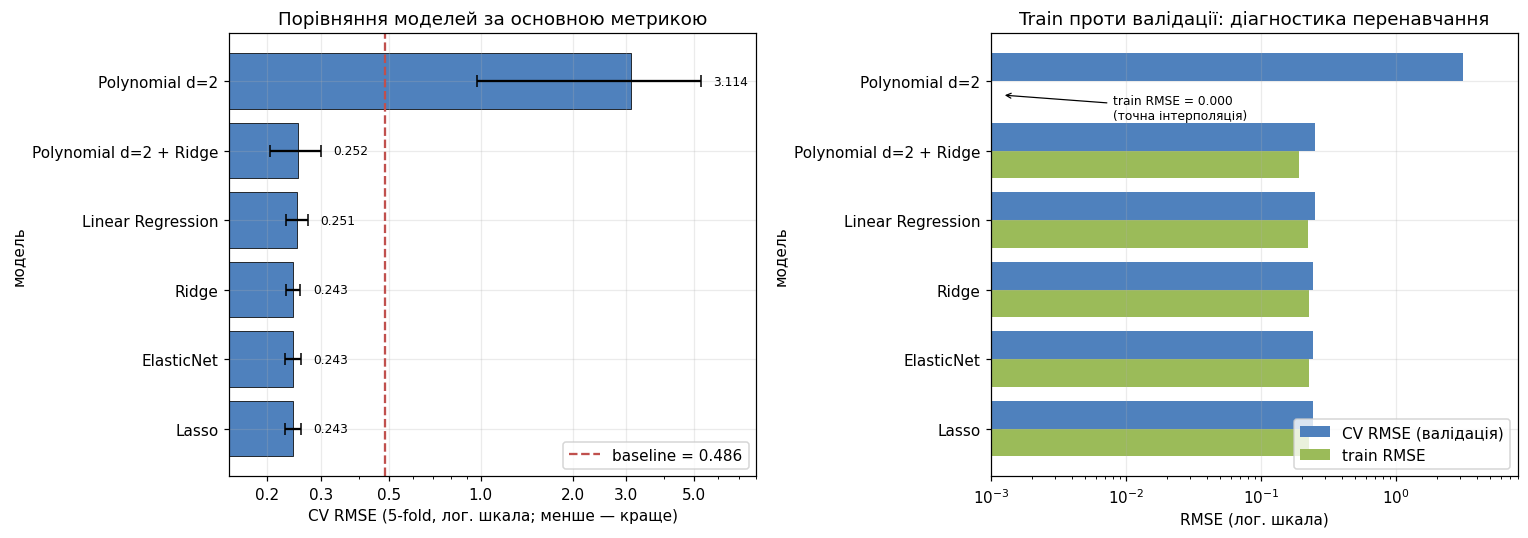

In [13]:
order = res.drop(index="Baseline (mean)").sort_values("CV RMSE")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Логарифмічна шкала: RMSE перенавченого поліному на порядок більший за решту,
# на лінійній шкалі всі інші моделі злилися б в одну смугу.
ax = axes[0]
ax.barh(order.index, order["CV RMSE"], xerr=order["CV std"], capsize=4,
        color="#4f81bd", edgecolor="black", linewidth=0.5)
ax.axvline(res.loc["Baseline (mean)", "CV RMSE"], color="#c0504d", linestyle="--",
           label=f"baseline = {res.loc['Baseline (mean)', 'CV RMSE']:.3f}")
ax.set_xscale("log")
ax.set_xlim(0.15, 8)
for i, (name, v) in enumerate(order["CV RMSE"].items()):
    ax.text((v + order["CV std"].iloc[i]) * 1.10, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xticks([0.2, 0.3, 0.5, 1, 2, 3, 5])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("CV RMSE (5-fold, лог. шкала; менше — краще)")
ax.set_ylabel("модель")
ax.set_title("Порівняння моделей за основною метрикою")
ax.legend(loc="lower right")

ax = axes[1]
idx = np.arange(len(order))
ax.barh(idx + 0.2, order["CV RMSE"], height=0.4, color="#4f81bd", label="CV RMSE (валідація)")
ax.barh(idx - 0.2, order["train RMSE"].clip(lower=1e-3), height=0.4,
        color="#9bbb59", label="train RMSE")
ax.set_xscale("log")
ax.set_xlim(1e-3, 8)
ax.set_yticks(idx)
ax.set_yticklabels(order.index)
ax.set_xlabel("RMSE (лог. шкала)")
ax.set_ylabel("модель")
ax.set_title("Train проти валідації: діагностика перенавчання")
poly_i = list(order.index).index("Polynomial d=2")
ax.annotate("train RMSE = 0.000\n(точна інтерполяція)", xy=(1.2e-3, poly_i - 0.2),
            xytext=(0.008, poly_i - 0.55), fontsize=8,
            arrowprops=dict(arrowstyle="->", linewidth=0.8))
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG / "02_cv_model_comparison.png")
plt.show()

## 8. Перевірка гіпотез практичної роботи № 1

У ПР № 1 я сформулювала 5 гіпотез. Перевіряю кожну **тим самим способом
крос-валідації**, щоб порівняння було чесним. Базою для порівняння беру
найкращу модель попереднього розділу.

In [14]:
# Надлишкові ознаки (гіпотеза 2): жадібно прибираємо по одній з кожної пари |r|>0.95
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = set()
for f1 in upper.index:
    for f2 in upper.columns:
        v = upper.loc[f1, f2]
        if pd.notna(v) and v > 0.95 and f1 not in redundant and f2 not in redundant:
            redundant.add(f2)
FEATURES_REDUCED = [f for f in FEATURES if f not in redundant]

# Шумові ознаки (гіпотеза 3): |r| з ціллю < 0.1
corr_t = X_train.corrwith(y_train)
noise = corr_t[corr_t.abs() < 0.1].index.tolist()
FEATURES_NO_NOISE = [f for f in FEATURES if f not in noise]

print(f"Гіпотеза 2 — надлишкових ознак при |r|>0.95: {len(redundant)} -> лишається {len(FEATURES_REDUCED)}")
print("  ", sorted(redundant))
print(f"\nГіпотеза 3 — шумових ознак при |r|<0.1: {len(noise)} -> лишається {len(FEATURES_NO_NOISE)}")
print("  ", noise)

Гіпотеза 2 — надлишкових ознак при |r|>0.95: 6 -> лишається 24
   ['area_mean', 'area_se', 'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_worst']

Гіпотеза 3 — шумових ознак при |r|<0.1: 5 -> лишається 25
   ['fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'fractal_dimension_se']


In [15]:
# Щоб порівнювати саме препроцесинг, а не моделі, усі варіанти нижче —
# та сама Ridge, і alpha в кожному варіанті підбирається за CV окремо.
print("Фіксуємо модель (Ridge) і міняємо лише препроцесинг / набір ознак.")

HYP = []


def hyp_eval(label, hypothesis, **pre_kw):
    gs = GridSearchCV(pipe(Ridge(random_state=RANDOM_STATE), **pre_kw),
                      {"model__alpha": np.logspace(-2, 4, 25)},
                      scoring="neg_root_mean_squared_error", cv=CV)
    gs.fit(X_train, y_train)
    r = cv_eval(label, gs.best_estimator_, store=False)
    r["гіпотеза"] = hypothesis
    r["alpha"] = gs.best_params_["model__alpha"]
    HYP.append(r)
    return r


hyp_eval("StandardScaler, 30 ознак (база)", "—")
hyp_eval("RobustScaler, 30 ознак", "Г5: стійке масштабування", scaler="robust")
hyp_eval("log1p(_se) + StandardScaler", "Г4: логарифм асиметричних _se", log_se=True)
hyp_eval(f"без надлишкових ({len(FEATURES_REDUCED)} ознак)", "Г2: мультиколінеарність",
         features=FEATURES_REDUCED)
hyp_eval(f"без шумових ({len(FEATURES_NO_NOISE)} ознак)", "Г3: неінформативні ознаки",
         features=FEATURES_NO_NOISE)

hyp = pd.DataFrame(HYP).set_index("model")[["гіпотеза", "CV RMSE", "CV std", "CV MAE", "CV R2", "alpha"]]
print(hyp.round(4).to_string())

Фіксуємо модель (Ridge) і міняємо лише препроцесинг / набір ознак.


                                                      гіпотеза  CV RMSE  CV std  CV MAE   CV R2    alpha
model                                                                                                   
StandardScaler, 30 ознак (база)                              —   0.2433  0.0128  0.1899  0.7416   3.1623
RobustScaler, 30 ознак                Г5: стійке масштабування   0.2429  0.0125  0.1895  0.7426   3.1623
log1p(_se) + StandardScaler      Г4: логарифм асиметричних _se   0.2368  0.0128  0.1854  0.7555   3.1623
без надлишкових (24 ознак)             Г2: мультиколінеарність   0.2496  0.0157  0.1968  0.7277  17.7828
без шумових (25 ознак)               Г3: неінформативні ознаки   0.2413  0.0157  0.1903  0.7451   1.7783


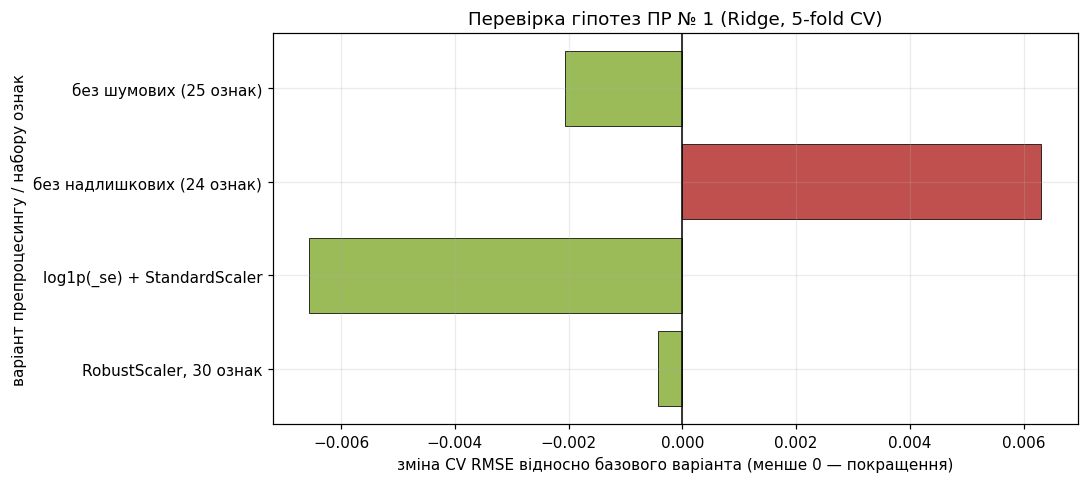

Стандартне відхилення RMSE між fold у базового варіанта: 0.0128
Зміни, менші за це значення, не можна вважати значущими.


In [16]:
base_rmse = hyp.loc["StandardScaler, 30 ознак (база)", "CV RMSE"]
delta = (hyp["CV RMSE"] - base_rmse).drop("StandardScaler, 30 ознак (база)")

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#c0504d" if d > 0 else "#9bbb59" for d in delta.values]
ax.barh(delta.index, delta.values, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("зміна CV RMSE відносно базового варіанта (менше 0 — покращення)")
ax.set_ylabel("варіант препроцесингу / набору ознак")
ax.set_title("Перевірка гіпотез ПР № 1 (Ridge, 5-fold CV)")
fig.tight_layout()
fig.savefig(FIG / "03_hypotheses_cv.png")
plt.show()

print("Стандартне відхилення RMSE між fold у базового варіанта:",
      round(hyp.loc["StandardScaler, 30 ознак (база)", "CV std"], 4))
print("Зміни, менші за це значення, не можна вважати значущими.")

Одного 5-fold прогону тут замало: найбільша зміна (`log1p`) менша за розкид RMSE
між fold, тож із цієї таблиці не видно, це реальний ефект чи випадковість
конкретного розбиття.

Перевіряю **повторною крос-валідацією** `RepeatedKFold(5×10)` = 50 fold і порівнюю
варіанти **попарно на тих самих розбиттях**. Парне порівняння прибирає спільну
дисперсію, спричинену «важкістю» конкретного fold, і показує не лише середню
різницю, а й наскільки вона стійка.

In [17]:
RKF = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

variants = {
    "база (StandardScaler, 30)": dict(),
    "RobustScaler": dict(scaler="robust"),
    "log1p(_se)": dict(log_se=True),
    f"без шумових ({len(FEATURES_NO_NOISE)})": dict(features=FEATURES_NO_NOISE),
    f"без надлишкових ({len(FEATURES_REDUCED)})": dict(features=FEATURES_REDUCED),
}

per_fold = {}
for name, kw in variants.items():
    gs = GridSearchCV(pipe(Ridge(random_state=RANDOM_STATE), **kw),
                      {"model__alpha": np.logspace(-2, 4, 25)},
                      scoring="neg_root_mean_squared_error", cv=CV).fit(X_train, y_train)
    per_fold[name] = -cross_val_score(gs.best_estimator_, X_train, y_train,
                                      cv=RKF, scoring="neg_root_mean_squared_error")

rep_tbl = pd.DataFrame({k: {"RMSE (5x10)": v.mean(), "std": v.std()} for k, v in per_fold.items()}).T
base_fold = per_fold["база (StandardScaler, 30)"]
rep_tbl["перевага над базою"] = [(base_fold - per_fold[k]).mean() for k in rep_tbl.index]
rep_tbl["кращий у fold"] = [f"{int(((base_fold - per_fold[k]) > 0).sum())}/50" for k in rep_tbl.index]
rep_tbl.loc["база (StandardScaler, 30)", ["перевага над базою", "кращий у fold"]] = [0.0, "—"]

print("Повторна крос-валідація 5x10, парне порівняння з базовим варіантом:")
print(rep_tbl.round(4).to_string())

Повторна крос-валідація 5x10, парне порівняння з базовим варіантом:
                           RMSE (5x10)     std  перевага над базою кращий у fold
база (StandardScaler, 30)       0.2434  0.0152              0.0000             —
RobustScaler                    0.2431  0.0151              0.0003         36/50
log1p(_se)                      0.2371  0.0135              0.0063         47/50
без шумових (25)                0.2410  0.0159              0.0024         31/50
без надлишкових (24)            0.2500  0.0144             -0.0066          4/50


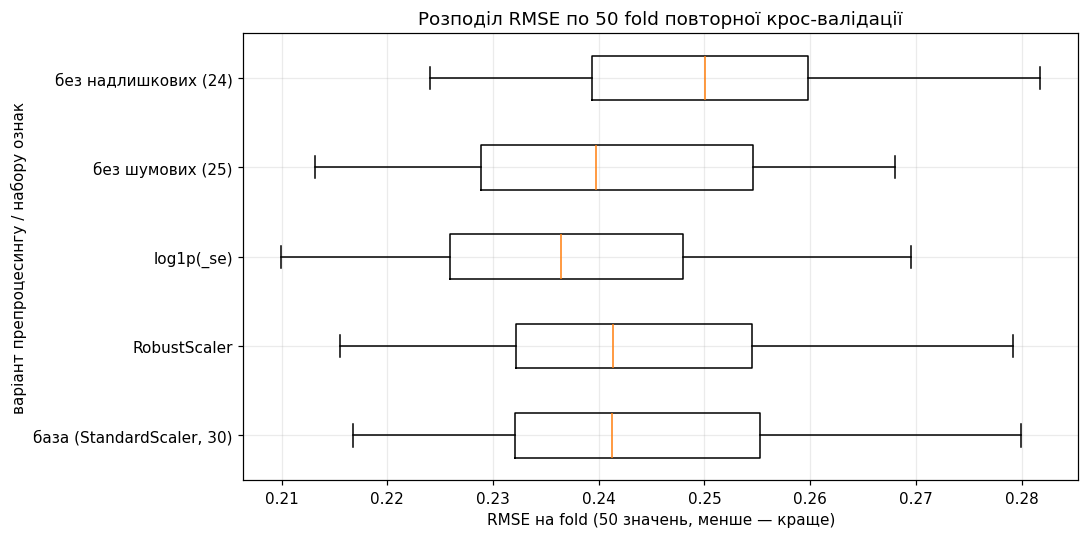

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(per_fold.keys())
ax.boxplot([per_fold[n] for n in names], tick_labels=names, vert=False)
ax.set_xlabel("RMSE на fold (50 значень, менше — краще)")
ax.set_ylabel("варіант препроцесингу / набору ознак")
ax.set_title("Розподіл RMSE по 50 fold повторної крос-валідації")
fig.tight_layout()
fig.savefig(FIG / "04_repeated_cv.png")
plt.show()

**Що вийшло з гіпотезами ПР № 1.**

| Гіпотеза з ПР № 1 | Результат перевірки |
|---|---|
| **Г1.** `_worst` та увігнутість — найкорисніші предиктори | **частково.** Серед 10 найбільших за модулем коефіцієнтів — 5 ознак `_worst` і 3 ознаки увігнутості (розділ 11). Але через мультиколінеарність модуль коефіцієнта тут поганий вимірювач важливості: сусідні ознаки одного кластера ділять вагу між собою і навіть отримують протилежні знаки |
| **Г2.** Кластер `radius/perimeter/area` надлишковий | **не підтвердилася.** Видалення 6 «надлишкових» ознак (|r|>0.95) **погіршило** RMSE. Ridge справляється з мультиколінеарністю стисканням коефіцієнтів краще, ніж грубе видалення стовпців за порогом кореляції |
| **Г3.** Частина ознак — шум для лінійної моделі | **не підтвердилася як покращення.** Видалення 5 ознак з |r|<0.1 дає перевагу лише у 31 fold із 50 — це рівень випадковості. Модель від них і не страждає: регуляризація сама притискає їхні коефіцієнти |
| **Г4.** Правоасиметричні `_se` виграють від `log1p` | **підтвердилася.** Перевага у **47 fold із 50**, середнє покращення RMSE ≈ 0.006. Це єдина зміна препроцесингу, що дала стійкий ефект |
| **Г5.** `RobustScaler` кращий за `StandardScaler` | **не підтвердилася.** Перевага +0.0003 і лише в 36 fold із 50 — у межах шуму. Причина зрозуміла: сильна асиметрія зосереджена у `_se`-ознаках, і `log1p` лікує її прицільніше, ніж заміна scaler для всіх 30 ознак одразу |

**Наслідок для фінальної моделі:** приймаю **одну** зміну препроцесингу —
`log1p` для `_se`-ознак. Решту гіпотез відхиляю, бо їхній ефект не відрізняється
від нуля. Рішення прийняте **виключно за навчальною вибіркою**; тестова досі не
використовувалася.

## 9. Фінальна модель і тестування

Фінальну модель обираю **до** того, як подивитися на тестову вибірку, — за
результатами крос-валідації, стабільністю між fold і простотою. Далі навчаю її на
**всій** навчальній вибірці й лише тоді одноразово оцінюю на тесті.

In [19]:
# Правило вибору сформульоване в плані (розділ 3) ДО перегляду результатів:
#   1) відкидаємо все, що не краще за baseline;
#   2) беремо найкращу CV RMSE і всі моделі в межах однієї CV std від неї
#      — між ними різниця статистично незначуща;
#   3) серед них обираємо НАЙСТАБІЛЬНІШУ (мінімальна std між fold).
# Крок 1. Тип моделі — за правилом із плану.
cand = res.drop(index="Baseline (mean)")
cand = cand[cand["CV RMSE"] < res.loc["Baseline (mean)", "CV RMSE"]]

best_rmse = cand["CV RMSE"].min()
tol = cand.loc[cand["CV RMSE"].idxmin(), "CV std"]
tie = cand[cand["CV RMSE"] <= best_rmse + tol]

print(f"Найкраща CV RMSE = {best_rmse:.4f} (модель {cand['CV RMSE'].idxmin()}), "
      f"CV std = {tol:.4f}")
print(f"У межах однієї CV std від неї — {len(tie)} моделей, різниця між ними незначуща:")
print(tie[["CV RMSE", "CV std"]].round(4).to_string())

BASE_MODEL = tie["CV std"].idxmin()
print(f"\nКрок 1 -> найстабільніша з них: {BASE_MODEL}")

# Крок 2. Препроцесинг — приймаємо єдину підтверджену зміну (гіпотеза 4).
gs_final = GridSearchCV(pipe(Ridge(random_state=RANDOM_STATE), log_se=True),
                        {"model__alpha": np.logspace(-2, 4, 25)},
                        scoring="neg_root_mean_squared_error", cv=CV).fit(X_train, y_train)
final_model = gs_final.best_estimator_
FINAL_ALPHA = gs_final.best_params_["model__alpha"]
FINAL_NAME = f"{BASE_MODEL} + log1p(_se)"
FINAL_CV_RMSE = -gs_final.best_score_

print(f"Крок 2 -> препроцесинг з log1p(_se): підтверджено у 47/50 fold")
print(f"\nФІНАЛЬНА МОДЕЛЬ: {FINAL_NAME}, alpha = {FINAL_ALPHA:.4g}, CV RMSE = {FINAL_CV_RMSE:.4f}")

final_model.fit(X_train, y_train)
baseline.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_base = baseline.predict(X_test)


def metrics(yt, yp):
    return {"MAE": mean_absolute_error(yt, yp),
            "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
            "R2": r2_score(yt, yp)}


test_tbl = pd.DataFrame({
    "Baseline (mean)": metrics(y_test, y_base),
    FINAL_NAME: metrics(y_test, y_pred),
}).T
test_tbl["покращення RMSE, %"] = [
    0.0, (1 - test_tbl.loc[FINAL_NAME, "RMSE"] / test_tbl.loc["Baseline (mean)", "RMSE"]) * 100]
print("\nРезультати на ТЕСТОВІЙ вибірці (114 об'єктів):")
print(test_tbl.round(4).to_string())

print(f"\nCV RMSE фінальної моделі був {FINAL_CV_RMSE:.4f}; "
      f"на тесті {test_tbl.loc[FINAL_NAME, 'RMSE']:.4f}. "
      f"Різниця {abs(FINAL_CV_RMSE - test_tbl.loc[FINAL_NAME, 'RMSE']):.4f} — "
      "у межах розкиду між fold, ознак перенавчання немає.")
print(f"Діапазон передбачень: [{y_pred.min():.3f}, {y_pred.max():.3f}] "
      f"(ціль набуває лише 0 або 1).")

# Post-hoc перевірка: чи допоможе обрізання передбачень у допустимий діапазон.
# Це перетворення НЕ бере участі у виборі моделі — просто дивимось наслідок.
clip_m = metrics(y_test, np.clip(y_pred, 0, 1))
print("\nЯкщо обрізати передбачення у [0, 1] (post-hoc, не входило у вибір моделі):")
print("   " + "  ".join(f"{k} = {v:.4f}" for k, v in clip_m.items()))

Найкраща CV RMSE = 0.2431 (модель Lasso), CV std = 0.0141
У межах однієї CV std від неї — 5 моделей, різниця між ними незначуща:
                        CV RMSE  CV std
model                                  
Linear Regression        0.2508  0.0203
Ridge                    0.2433  0.0128
Lasso                    0.2431  0.0141
ElasticNet               0.2432  0.0142
Polynomial d=2 + Ridge   0.2522  0.0477

Крок 1 -> найстабільніша з них: Ridge


Крок 2 -> препроцесинг з log1p(_se): підтверджено у 47/50 fold

ФІНАЛЬНА МОДЕЛЬ: Ridge + log1p(_se), alpha = 3.162, CV RMSE = 0.2368

Результати на ТЕСТОВІЙ вибірці (114 об'єктів):
                       MAE    RMSE      R2  покращення RMSE, %
Baseline (mean)     0.4667  0.4824 -0.0001               0.000
Ridge + log1p(_se)  0.2048  0.2494  0.7326              48.294

CV RMSE фінальної моделі був 0.2368; на тесті 0.2494. Різниця 0.0127 — у межах розкиду між fold, ознак перенавчання немає.
Діапазон передбачень: [-0.448, 1.413] (ціль набуває лише 0 або 1).

Якщо обрізати передбачення у [0, 1] (post-hoc, не входило у вибір моделі):
   MAE = 0.1655  RMSE = 0.2308  R2 = 0.7710


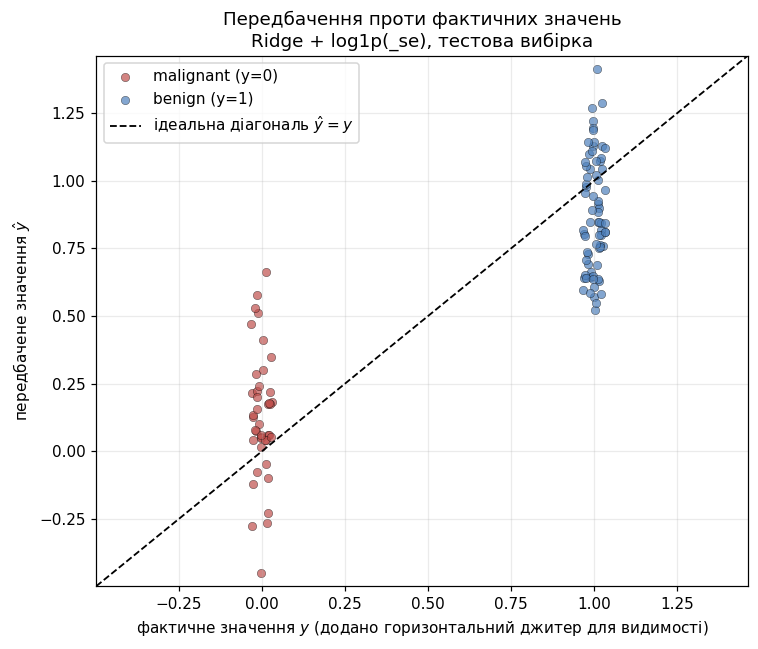

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
jitter = np.random.default_rng(RANDOM_STATE).uniform(-0.035, 0.035, size=len(y_test))
for cls, color, name in [(0, "#c0504d", "malignant (y=0)"), (1, "#4f81bd", "benign (y=1)")]:
    m = y_test.values == cls
    ax.scatter(y_test.values[m] + jitter[m], y_pred[m], s=30, alpha=0.7,
               color=color, edgecolor="black", linewidth=0.3, label=name)
lims = [min(-0.35, y_pred.min() - 0.05), max(1.35, y_pred.max() + 0.05)]
ax.plot(lims, lims, "k--", linewidth=1.2, label="ідеальна діагональ $\\hat y = y$")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("фактичне значення $y$ (додано горизонтальний джитер для видимості)")
ax.set_ylabel("передбачене значення $\\hat y$")
ax.set_title(f"Передбачення проти фактичних значень\n{FINAL_NAME}, тестова вибірка")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG / "05_pred_vs_true.png")
plt.show()

## 10. Аналіз похибок

Залишки: $e_i = y_i - \hat y_i$.

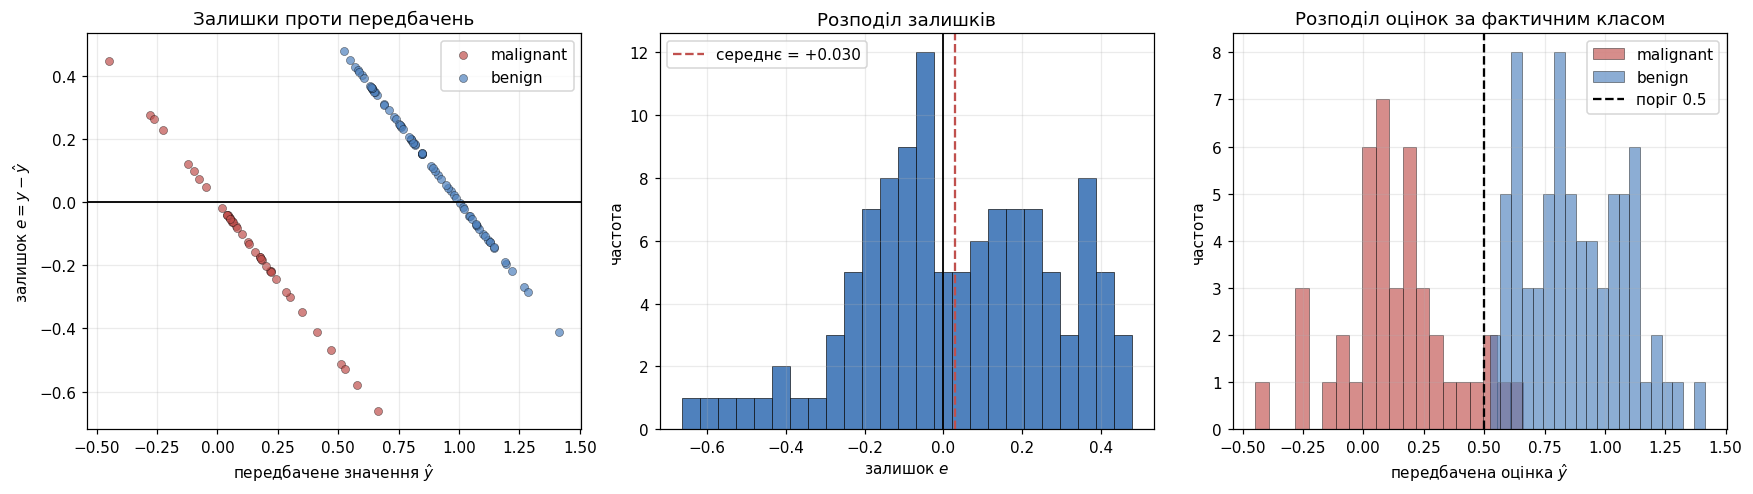

середній залишок      = +0.0296  (систематичного зсуву практично немає)
медіанний залишок     = +0.0049
std залишків          = 0.2477
частка |e| > 0.5      = 3.5%


In [21]:
resid = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
for cls, color, name in [(0, "#c0504d", "malignant"), (1, "#4f81bd", "benign")]:
    m = y_test.values == cls
    ax.scatter(y_pred[m], resid[m], s=28, alpha=0.7, color=color,
               edgecolor="black", linewidth=0.3, label=name)
ax.axhline(0, color="black", linewidth=1.2)
ax.set_xlabel("передбачене значення $\\hat y$")
ax.set_ylabel("залишок $e = y - \\hat y$")
ax.set_title("Залишки проти передбачень")
ax.legend()

ax = axes[1]
ax.hist(resid, bins=25, color="#4f81bd", edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=1.2)
ax.axvline(resid.mean(), color="#c0504d", linestyle="--",
           label=f"середнє = {resid.mean():+.3f}")
ax.set_xlabel("залишок $e$")
ax.set_ylabel("частота")
ax.set_title("Розподіл залишків")
ax.legend()

ax = axes[2]
ax.hist(y_pred[y_test.values == 0], bins=20, alpha=0.65, color="#c0504d",
        label="malignant", edgecolor="black", linewidth=0.4)
ax.hist(y_pred[y_test.values == 1], bins=20, alpha=0.65, color="#4f81bd",
        label="benign", edgecolor="black", linewidth=0.4)
ax.axvline(0.5, color="black", linestyle="--", label="поріг 0.5")
ax.set_xlabel("передбачена оцінка $\\hat y$")
ax.set_ylabel("частота")
ax.set_title("Розподіл оцінок за фактичним класом")
ax.legend()

fig.tight_layout()
fig.savefig(FIG / "06_residuals.png")
plt.show()

print(f"середній залишок      = {resid.mean():+.4f}  (систематичного зсуву практично немає)")
print(f"медіанний залишок     = {np.median(resid):+.4f}")
print(f"std залишків          = {resid.std():.4f}")
print(f"частка |e| > 0.5      = {(np.abs(resid) > 0.5).mean() * 100:.1f}%")

In [22]:
err = pd.DataFrame({
    "y_факт": y_test.values,
    "y_передбачене": y_pred.round(3),
    "|похибка|": np.abs(resid).round(3),
}, index=y_test.index).sort_values("|похибка|", ascending=False)

top = err.head(5)
print("П'ять об'єктів із найбільшою абсолютною похибкою:")
print(top.to_string())

key = ["concave_points_worst", "perimeter_worst", "area_worst", "radius_mean",
       "texture_mean", "area_se"]
cmp = X_test.loc[top.index, key].copy()
cmp.loc["медіана malignant (train)"] = X_train[y_train == 0][key].median()
cmp.loc["медіана benign (train)"] = X_train[y_train == 1][key].median()
print("\nЗначення ключових ознак цих об'єктів проти типових значень класів:")
print(cmp.round(3).to_string())

П'ять об'єктів із найбільшою абсолютною похибкою:
     y_факт  y_передбачене  |похибка|
73      0.0          0.663      0.663
194     0.0          0.578      0.578
41      0.0          0.529      0.529
261     0.0          0.512      0.512
541     1.0          0.523      0.477

Значення ключових ознак цих об'єктів проти типових значень класів:
                           concave_points_worst  perimeter_worst  area_worst  radius_mean  texture_mean  area_se
73                                        0.138           110.30       812.4       13.800        15.790    23.35
194                                       0.173           118.60       784.7       14.860        23.210    25.20
41                                        0.142            87.22       514.0       10.950        21.350    16.97
261                                       0.082           128.20      1218.0       17.350        23.060    44.41
541                                       0.120           113.50       808.9       14.470

## 11. Практична придатність: від оцінки до рішення

Регресійні метрики самі по собі не відповідають на питання «чи корисна модель
лікарю». Оскільки ціль бінарна, додатково дивлюся, що станеться, якщо
інтерпретувати оцінку як рішення за порогом 0.5, і скільки випадків потрапляє в
«сіру зону» невпевненості. Це не заміна регресійних метрик, а спосіб перекласти
їх у практичну площину.

In [23]:
pred_cls = (y_pred >= 0.5).astype(int)
acc = (pred_cls == y_test.values).mean()
fn = int(((pred_cls == 1) & (y_test.values == 0)).sum())   # злоякісне названо доброякісним
fp = int(((pred_cls == 0) & (y_test.values == 1)).sum())

print(f"Частка правильних рішень за порогом 0.5: {acc * 100:.1f}% ({int((pred_cls == y_test.values).sum())} зі {len(y_test)})")
print(f"  злоякісне помилково оцінено як доброякісне: {fn}  <- найдорожча помилка")
print(f"  доброякісне помилково оцінено як злоякісне: {fp}")

grey = (y_pred > 0.3) & (y_pred < 0.7)
print(f"\n«Сіра зона» 0.3 < y_hat < 0.7: {grey.sum()} об'єктів ({grey.mean() * 100:.1f}%)")
if grey.sum():
    print(f"  точність рішень у сірій зоні: {(pred_cls[grey] == y_test.values[grey]).mean() * 100:.0f}%")
print(f"  точність поза сірою зоною:     {(pred_cls[~grey] == y_test.values[~grey]).mean() * 100:.0f}%")

out_range = ((y_pred < 0) | (y_pred > 1)).sum()
print(f"\nПередбачень поза [0, 1]: {out_range} ({out_range / len(y_pred) * 100:.1f}%) — "
      "лінійна модель не обмежена діапазоном цілі.")

Частка правильних рішень за порогом 0.5: 96.5% (110 зі 114)
  злоякісне помилково оцінено як доброякісне: 4  <- найдорожча помилка
  доброякісне помилково оцінено як злоякісне: 0

«Сіра зона» 0.3 < y_hat < 0.7: 26 об'єктів (22.8%)
  точність рішень у сірій зоні: 85%
  точність поза сірою зоною:     100%

Передбачень поза [0, 1]: 31 (27.2%) — лінійна модель не обмежена діапазоном цілі.


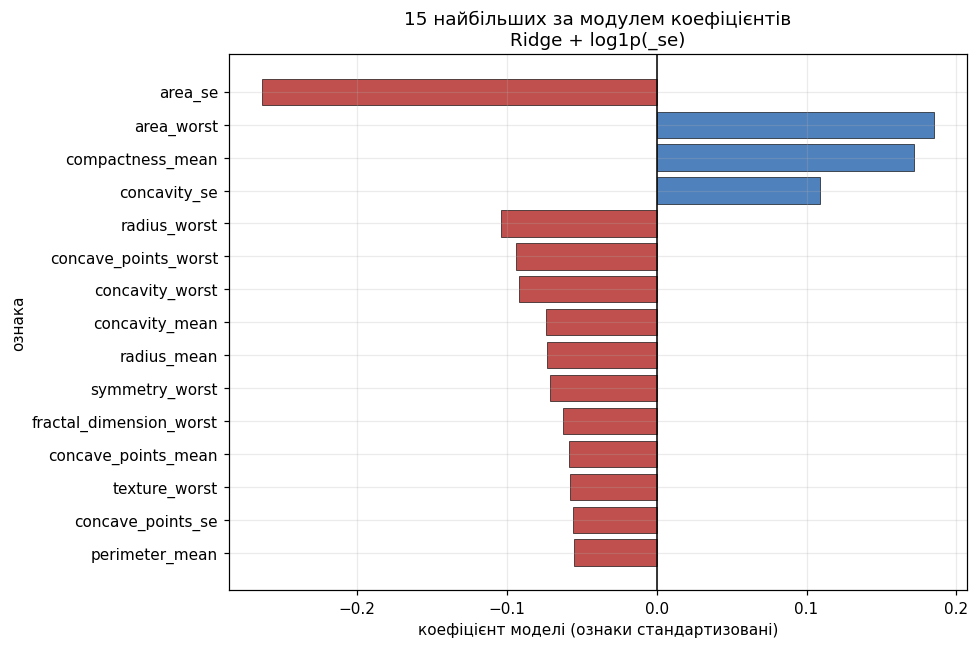

Топ-10 за модулем:
area_se                -0.2632
area_worst              0.1849
compactness_mean        0.1715
concavity_se            0.1090
radius_worst           -0.1040
concave_points_worst   -0.0936
concavity_worst        -0.0917
concavity_mean         -0.0737
radius_mean            -0.0733
symmetry_worst         -0.0710

Частка _worst серед топ-10: 5/10


In [24]:
# Гіпотеза 1 з ПР № 1: чи справді _worst та увігнутість — найкорисніші ознаки
model_step = final_model.named_steps["model"]
# після log1p препроцесор має дві гілки, тож порядок стовпців беремо з нього самого
names = [n.split("__", 1)[-1] for n in final_model.named_steps["pre"].get_feature_names_out()]
coefs = pd.Series(model_step.coef_, index=names).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top_c = coefs.head(15).iloc[::-1]
ax.barh(top_c.index, top_c.values,
        color=["#c0504d" if v < 0 else "#4f81bd" for v in top_c.values],
        edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("коефіцієнт моделі (ознаки стандартизовані)")
ax.set_ylabel("ознака")
ax.set_title(f"15 найбільших за модулем коефіцієнтів\n{FINAL_NAME}")
fig.tight_layout()
fig.savefig(FIG / "07_top_coefficients.png")
plt.show()

print("Топ-10 за модулем:")
print(coefs.head(10).round(4).to_string())
print("\nЧастка _worst серед топ-10:",
      f"{sum('_worst' in f for f in coefs.head(10).index)}/10")